In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df = pd.read_csv('../Data/processed/Gurgaon_merged_v3.csv')
df

,property_type,society,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.000000,900.0,2,2,1,4.0,...,900.0,NaN,NaN,0,0,0,0,0,2,28
1,flat,apna enclave,sector 5,0.50,7692.000000,650.0,2,2,1,1.0,...,650.0,NaN,NaN,0,0,0,0,0,0,37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.000000,595.0,2,2,3,12.0,...,595.0,NaN,NaN,0,0,0,0,0,2,36
3,flat,smart world orchard,sector 61,1.47,12250.000000,1200.0,2,2,2,2.0,...,1200.0,NaN,NaN,1,0,0,0,0,2,76
4,flat,parkwood westend,sector 92,0.70,5204.000000,1345.0,2,2,3,5.0,...,NaN,NaN,NaN,1,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3848,house,dlf city phase 1,sector 26,5.50,30555.555556,1800.0,4,4,3,2.0,...,NaN,200.0,NaN,1,1,1,0,0,2,69
3849,house,dlf city plots phase 2,sector 25,4.25,31481.481481,1350.0,3,2,3,2.0,...,NaN,150.0,NaN,1,0,0,0,0,2,35
3850,house,dlf city phase 1,sector 26,4.50,33333.333333,1350.0,3,3,2,2.0,...,NaN,150.0,NaN,1,1,0,0,0,2,70
3851,house,dlf city phase 1,sector 26,3.25,3681.051082,8829.0,3,3,3,2.0,...,NaN,109.0,NaN,1,0,0,0,0,2,79


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3853 entries, 0 to 3852
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3853 non-null   object 
 1   society              3853 non-null   object 
 2   sector               3853 non-null   object 
 3   price                3853 non-null   float64
 4   price_per_sqft       3853 non-null   float64
 5   area                 3853 non-null   float64
 6   bedRoom              3853 non-null   int64  
 7   bathroom             3853 non-null   int64  
 8   balcony              3853 non-null   object 
 9   floorNum             3831 non-null   float64
 10  facing               2697 non-null   object 
 11  agePossession        3853 non-null   object 
 12  super_built_up_area  1932 non-null   float64
 13  carpet_area          1971 non-null   float64
 14  Plot_area            685 non-null    float64
 15  built_up_area        1205 non-null   f

In [99]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 22
facing                 1156
agePossession             0
super_built_up_area    1921
carpet_area            1882
Plot_area              3168
built_up_area          2648
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [100]:
df.drop(columns=['facing'], inplace=True)

In [101]:
df.floorNum.fillna(df.floorNum.median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\2729066821.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.floorNum.fillna(df.floorNum.median(), inplace=True)


In [102]:
df.isnull().sum ()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                  0
agePossession             0
super_built_up_area    1921
carpet_area            1882
Plot_area              3168
built_up_area          2648
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [103]:
# Super Built-up / Built-up
super_to_built = (
    df.dropna(subset=['super_built_up_area', 'built_up_area'])['super_built_up_area'].median()
    / df.dropna(subset=['super_built_up_area', 'built_up_area'])['built_up_area'].median()
)

# Built-up / Super Built-up
built_to_super = (
    df.dropna(subset=['super_built_up_area', 'built_up_area'])['built_up_area'].median()
    / df.dropna(subset=['super_built_up_area', 'built_up_area'])['super_built_up_area'].median()
)

# Super Built-up / Carpet
super_to_carpet = (
    df.dropna(subset=['super_built_up_area', 'carpet_area'])['super_built_up_area'].median()
    / df.dropna(subset=['super_built_up_area', 'carpet_area'])['carpet_area'].median()
)

# Carpet / Super Built-up
carpet_to_super = (
    df.dropna(subset=['super_built_up_area', 'carpet_area'])['carpet_area'].median()
    / df.dropna(subset=['super_built_up_area', 'carpet_area'])['super_built_up_area'].median()
)

# Built-up / Carpet
built_to_carpet = (
    df.dropna(subset=['built_up_area', 'carpet_area'])['built_up_area'].median()
    / df.dropna(subset=['built_up_area', 'carpet_area'])['carpet_area'].median()
)

# Carpet / Built-up
carpet_to_built = (
    df.dropna(subset=['built_up_area', 'carpet_area'])['carpet_area'].median()
    / df.dropna(subset=['built_up_area', 'carpet_area'])['built_up_area'].median()
)

# Plot / Built-up
plot_to_built = (
    df.dropna(subset=['Plot_area', 'built_up_area'])['Plot_area'].median()
    / df.dropna(subset=['Plot_area', 'built_up_area'])['built_up_area'].median()
)

# Built-up / Plot
built_to_plot = (
    df.dropna(subset=['Plot_area', 'built_up_area'])['built_up_area'].median()
    / df.dropna(subset=['Plot_area', 'built_up_area'])['Plot_area'].median()
)

# Plot / Carpet
plot_to_carpet = (
    df.dropna(subset=['Plot_area', 'carpet_area'])['Plot_area'].median()
    / df.dropna(subset=['Plot_area', 'carpet_area'])['carpet_area'].median()
)

# Carpet / Plot
carpet_to_plot = (
    df.dropna(subset=['Plot_area', 'carpet_area'])['carpet_area'].median()
    / df.dropna(subset=['Plot_area', 'carpet_area'])['Plot_area'].median()
)


In [104]:
ratios = {
    "Super Built-up / Built-up": super_to_built,
    "Built-up / Super Built-up": built_to_super,
    "Super Built-up / Carpet": super_to_carpet,
    "Carpet / Super Built-up": carpet_to_super,
    "Built-up / Carpet": built_to_carpet,
    "Carpet / Built-up": carpet_to_built,
    "Plot / Built-up": plot_to_built,
    "Built-up / Plot": built_to_plot,
    "Plot / Carpet": plot_to_carpet,
    "Carpet / Plot": carpet_to_plot,
}

for name, value in ratios.items():
    print(f"{name:<30}: {value:.3f}")

Super Built-up / Built-up     : 1.135
Built-up / Super Built-up     : 0.881
Super Built-up / Carpet       : 1.341
Carpet / Super Built-up       : 0.746
Built-up / Carpet             : 1.185
Carpet / Built-up             : 0.844
Plot / Built-up               : 0.556
Built-up / Plot               : 1.800
Plot / Carpet                 : 0.673
Carpet / Plot                 : 1.485


In [105]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,2,2,1,4.0,...,900.0,NaN,NaN,0,0,0,0,0,2,28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,2,2,1,1.0,...,650.0,NaN,NaN,0,0,0,0,0,0,37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,2,2,3,12.0,...,595.0,NaN,NaN,0,0,0,0,0,2,36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,2,2,2,2.0,...,1200.0,NaN,NaN,1,0,0,0,0,2,76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,2,2,3,5.0,...,NaN,NaN,NaN,1,0,0,0,0,2,0


In [106]:
sbc_df = df[~df.super_built_up_area.isnull() & df.built_up_area.isnull() & ~df.carpet_area.isnull()]

In [107]:
sbc_df.built_up_area.fillna((ratios["Super Built-up / Built-up"] + ratios["Carpet / Built-up"]), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\3863733875.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df.built_up_area.fillna((ratios["Super Built-up / Built-up"] + ratios["Carpet / Built-up"]), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\3863733875.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df.b

In [108]:
df.update(sbc_df)

In [119]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                  0
agePossession             0
super_built_up_area    1921
carpet_area            1882
Plot_area              3168
built_up_area             0
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [110]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [111]:
sb_df.built_up_area.fillna(sb_df.super_built_up_area / 1.135, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\961803482.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df.built_up_area.fillna(sb_df.super_built_up_area / 1.135, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\961803482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df.built_up_area.fillna(sb_df.super_built_

In [112]:
df.update(sb_df)

In [113]:
# sb null c is present built up null
c_df = df[(df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [114]:
c_df.built_up_area.fillna(c_df.carpet_area /0.844, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\4105299550.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df.built_up_area.fillna(c_df.carpet_area /0.844, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\4105299550.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df.built_up_area.fillna(c_df.carpet_area /0.844, inp

In [115]:
df.update(c_df)

In [120]:
df[df.built_up_area.isnull()]

,property_type,society,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score


In [118]:
df.built_up_area.fillna(df.Plot_area / 0.556, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_31992\4164169501.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.built_up_area.fillna(df.Plot_area / 0.556, inplace=True)


In [121]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                  0
agePossession             0
super_built_up_area    1921
carpet_area            1882
Plot_area              3168
built_up_area             0
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

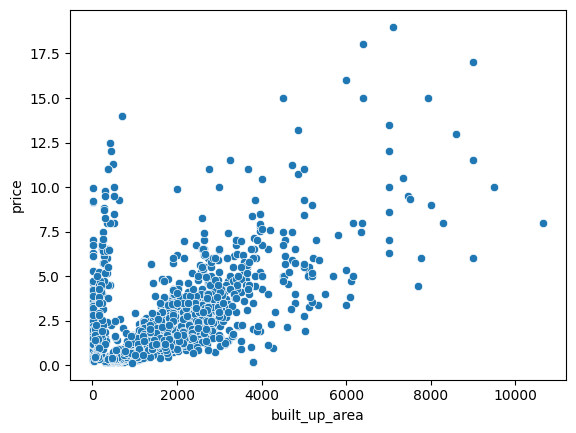

In [117]:
sns.scatterplot( x = df.built_up_area, y = df.price)

In [122]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [123]:
anamoly_df.head()

,price,area,built_up_area
23,2.85,2217.0,1953.303965
30,3.25,3200.0,1.979044
48,2.80,1650.0,1954.976303
76,2.70,2159.0,1902.202643
83,3.87,2250.0,1.979044


In [124]:
anamoly_df.built_up_area = anamoly_df.area

In [125]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

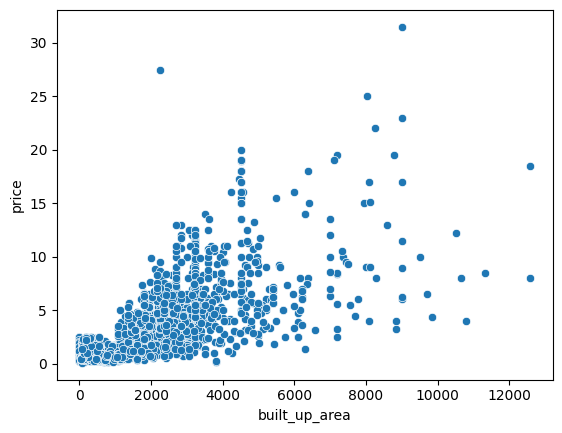

In [126]:
sns.scatterplot(x='built_up_area', y='price', data=df)

In [127]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                  0
agePossession             0
super_built_up_area    1921
carpet_area            1882
Plot_area              3168
built_up_area             0
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [128]:
df.drop(columns = ['Plot_area', 'super_built_up_area','carpet_area'], inplace=True)

In [129]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
area               0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
pooja room         0
store room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [131]:
from pathlib import Path

Data_path = Path('../Data/processed/Gurgaon_cleaned_final.csv')
df.to_csv(Data_path, index=False)

In [132]:
df.shape

(3853, 19)